## Human in the loop

Review for Human-in-the-loop, we often want to see our graph outputs as it is runnung.
We laid the foundations of that with **streaming**.

**Goals**. Motivations for Human-in-the-loop:
1. **Approval** - We can interupt our agent, surface state to a user, and allow the user to accept the action.
2. **Debugging** - We can rewind the graph to reproduce or avoid issues.
3. **Edditing** - You can modify the state.

**Langgraph** offers several to get or update agent state to support various **human-in-the-loop** workflows.

In [ ]:
import os
from dotenv import load_dotenv

ENV_PATH = '../.env'
assert os.path.exists(ENV_PATH)

load_dotenv('../.env')

GROQ_API_KEY = os.environ['GROQ_API_KEY']
assert GROQ_API_KEY
print(f'----> GROQ_API_KEY: {GROQ_API_KEY[:3]}***{GROQ_API_KEY[-3:]}')


LANGCHAIN_API_KEY = os.environ['LANGCHAIN_API_KEY']
assert LANGCHAIN_API_KEY
print(f'----> LANGCHAIN_API_KEY: {LANGCHAIN_API_KEY[:3]}***{LANGCHAIN_API_KEY[-3:]}')

# Required by LangChain 
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
LANGCHAIN_PROJECT = 'Human in the loop example'
os.environ['LANGCHAIN_PROJECT'] = LANGCHAIN_PROJECT
print(f'----> LANGCHAIN_PROJECT: {LANGCHAIN_PROJECT}')

----> GROQ_API_KEY: gsk***qNU
----> LANGCHAIN_API_KEY: lsv***43b
---->LANGCHAIN_PROJECT: Human in the loop example


##### Create some custom tools

In [3]:
from langchain.tools import tool, BaseTool

@tool(
    name_or_callable="multiply_numbers",
    description="Multiplies two numbers and returns the product. Use this tool whenever you need to calculate the result of one number times another."
)
def multiply_numbers(a: float, b: float) -> float:
    return a * b

@tool(
    name_or_callable="add_numbers",
    description="Adds two numbers and returns the sum. Use this tool whenever you need to calculate the result of one number plus another."
)
def add_numbers(a: float, b: float) -> float:
    return a + b

@tool(
    name_or_callable="divide_numbers",
    description="Divides the first number by the second number and returns the quotient. Use this tool whenever you need to calculate one number divided by another. Note: if the second number is 0, handle it gracefully."
)
def divide_numbers(a: float, b: float) -> float:
    if b == 0:
        raise ValueError("Division by zero is not allowed.")
    return a / b

math_tools = [multiply_numbers, add_numbers, divide_numbers]

for math_tool in math_tools:
    assert isinstance(math_tool, BaseTool)

In [4]:
from langchain_groq import ChatGroq

#LLM temperature is a parameter that controls the randomness and creativity of a large language model's output by adjusting the probability distribution of next-word predictions. Lower temperatures (e.g., <0.5) make the output more predictable and deterministic, favoring more common, "safer" words, which is good for factual accuracy. Higher temperatures (e.g., >0.8) increase randomness, leading to more varied, creative, and surprising outputs, ideal for tasks like brainstorming or storytelling. 
llm = ChatGroq(model='qwen/qwen3-32b', temperature=0, reasoning_format='hidden')
llm_with_tools = llm.bind_tools(math_tools)
llm_with_tools

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x10e44eba0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10e44f770>, model_name='qwen/qwen3-32b', temperature=1e-08, reasoning_format='hidden', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'multiply_numbers', 'description': 'Multiplies two numbers and returns the product. Use this tool whenever you need to calculate the result of one number times another.', 'parameters': {'properties': {'a': {'type': 'number'}, 'b': {'type': 'number'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'add_numbers', 'description': 'Adds two numbers and returns the sum. Use this tool whenever you need to calculate the result of one number plus another.', 'parameters': {'properties': {'a': {'type': 'number'}, 'b': {'type': 'number'}}, 'required': ['a', 'b'], 'type': 'object'

### Create a workflow in **Langgraph**

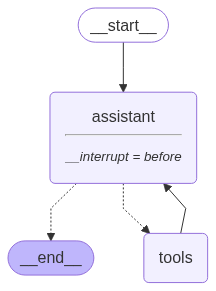

In [6]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import MessagesState
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage

system_prompt = """
You are an assistant that can perform arithmetic operations.  
You have access to specialized tools: add_numbers, multiply_numbers, divide_numbers.  

Guidelines:  
- Whenever you need to perform arithmetic, prefer using the provided tools instead of calculating internally.  
- Only use mental math for very simple cases (e.g., 1+1=2), otherwise rely on the tools.  
- Always provide clear and correct results to the user.  
- If division by zero is attempted, handle it gracefully by explaining the error instead of forcing a calculation.  
- Respond with both the result and a short explanation of what was done.
"""
system_message = SystemMessage(content=system_prompt)

## Graph nodes
def assistant(state: MessagesState) -> MessagesState:
    input_msgs = [system_message] + state['messages']
    return { 'messages': [llm_with_tools.invoke(input=input_msgs)] }

graph_builder = StateGraph(MessagesState)

# Add nodes
graph_builder.add_node('assistant', assistant)
graph_builder.add_node('tools', ToolNode(tools=math_tools))

# Add edges
graph_builder.add_edge(START, 'assistant')
graph_builder.add_conditional_edges('assistant', tools_condition)
graph_builder.add_edge('tools', 'assistant')

memory = MemorySaver()

# Human in the loop
graph = graph_builder.compile(interrupt_before=['assistant'],
                              checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

#### Execute the graph

In [7]:
config = { 'configurable': { 'thread_id': '1' } }
input_state: MessagesState = { 'messages': 'What is the sum of 1423 and 23411' }

for event in graph.stream(input=input_state, config=config, stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

What is the sum of 1423 and 23411


In [10]:
state = graph.get_state(config=config)
state.next

('assistant',)

In [12]:
# Continue the execution
for event in graph.stream(input=None, config=config, stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

What is the sum of 1423 and 23411
================================== Ai Message ==================================
Tool Calls:
  add_numbers (6km1j5p0k)
 Call ID: 6km1j5p0k
  Args:
    a: 1423
    b: 23411
================================= Tool Message =================================
Name: add_numbers

24834.0


In [13]:
## Check state again
state = graph.get_state(config=config)
state

StateSnapshot(values={'messages': [HumanMessage(content='What is the sum of 1423 and 23411', additional_kwargs={}, response_metadata={}, id='d1297a66-2bfa-4d2a-acd8-ad4129ec2c30'), HumanMessage(content='What is the sum of 1423 and 23411', additional_kwargs={}, response_metadata={}, id='0421a14d-0c53-4980-9efa-f86e47ded8f7'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6km1j5p0k', 'function': {'arguments': '{"a":1423,"b":23411}', 'name': 'add_numbers'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 181, 'prompt_tokens': 535, 'total_tokens': 716, 'completion_time': 0.61631165, 'prompt_time': 0.033328701, 'queue_time': 0.088799394, 'total_time': 0.649640351}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--25d826a5-22b6-4258-9d02-4650bc7889df-0', tool_calls=[{'name': 'add_numbers', 'args': {'a': 1423, 'b': 23411}, 'id': '6km1j5

In [14]:
# Continue execution again
for event in graph.stream(input=None, config=config, stream_mode='values'):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: add_numbers

24834.0
================================== Ai Message ==================================

The sum of 1423 and 23,411 is **24,834**. I used the `add_numbers` tool to calculate this result. 

Let me know if you need further assistance!


## Edit the Human feedback

In [15]:
config = { 'configurable': { 'thread_id': '2' } }
input_state: MessagesState = { 'messages': [HumanMessage(content='Multiply 1914 and 1892')] }

for event in graph.stream(input=input_state, config=config, stream_mode='values'):
    print(type(event))
    event['messages'][-1].pretty_print()

<class 'dict'>
================================ Human Message =================================

Multiply 1914 and 1892


In [16]:
graph.update_state(config=config, values={
    'messages': [HumanMessage(content='My mistake, multiply 1914 and 777')]
})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f08c993-8c5d-6dc0-8001-f478dcc4d479'}}

In [19]:
state = graph.get_state(config=config)
for m in state.values['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 1914 and 1892
================================ Human Message =================================

My mistake, multiply 1914 and 777


In [20]:
# Continue execution again
for event in graph.stream(input=None, config=config, stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

My mistake, multiply 1914 and 777
================================== Ai Message ==================================
Tool Calls:
  multiply_numbers (6vd2h7krr)
 Call ID: 6vd2h7krr
  Args:
    a: 1914
    b: 777
================================= Tool Message =================================
Name: multiply_numbers

1487178.0


In [21]:
# Continue execution again
for event in graph.stream(input=None, config=config, stream_mode='values'):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply_numbers

1487178.0
================================== Ai Message ==================================

The product of 1914 multiplied by 777 is **1,487,178**. 

I used the `multiply_numbers` tool to calculate this result. Let me know if you need any other calculations!


### Workflow will Wait for User message

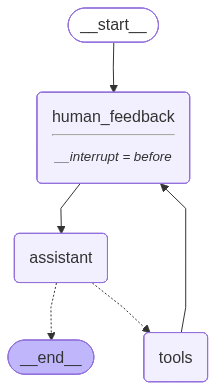

In [36]:
system_prompt = """
You are an assistant that can perform arithmetic operations.  
You have access to specialized tools: add_numbers, multiply_numbers, divide_numbers.  

Guidelines:  
- Whenever you need to perform arithmetic, prefer using the provided tools instead of calculating internally.  
- Only use mental math for very simple cases (e.g., 1+1=2), otherwise rely on the tools.  
- Always provide clear and correct results to the user.  
- If division by zero is attempted, handle it gracefully by explaining the error instead of forcing a calculation.  
- Respond with both the result and a short explanation of what was done.
"""
system_message = SystemMessage(content=system_prompt)

# Human feedback node
def human_feedback(state: MessagesState) -> MessagesState:
    pass

# Assistant node
def assistant(state: MessagesState) -> MessagesState:
    input_msgs = [system_message] + state["messages"]
    print(f'Calling LLM with {input_msgs}')
    return { 'messages': llm_with_tools.invoke(input=input_msgs) }

graph_builder = StateGraph(MessagesState)

# Add nodes
graph_builder.add_node('assistant', assistant)
graph_builder.add_node('human_feedback', human_feedback)
graph_builder.add_node('tools', ToolNode(math_tools))

# Add edges
graph_builder.add_edge(START, 'human_feedback')
graph_builder.add_edge('human_feedback', 'assistant')
graph_builder.add_conditional_edges('assistant', tools_condition)
graph_builder.add_edge('tools', 'human_feedback')
# graph_builder.add_edge('assistant', END)

memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory, interrupt_before=['human_feedback'])

display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
import uuid

# Config
config = { 'configurable': { 'thread_id': str(uuid.uuid4()) } }
print(f'Configurable: {config}')

input_state: MessagesState = { 'messages': [
    HumanMessage(content='Multiply 234 and 8.9')
]}

Configurable: {'configurable': {'thread_id': 'c304fc2c-ba90-4b39-8869-29b1bc13af40'}}


In [38]:
# Run the graph until first interuption
for event in graph.stream(input=input_state, config=config, stream_mode='values'):
    event['messages'][-1].pretty_print()

# Get user input
user_input = input('How you want to update the state: ')
graph.update_state(config=config, values={
    'messages': [HumanMessage(content=user_input)]
}, as_node='human_feedback')

================================ Human Message =================================

Multiply 234 and 8.9


{'configurable': {'thread_id': 'c304fc2c-ba90-4b39-8869-29b1bc13af40',
  'checkpoint_ns': '',
  'checkpoint_id': '1f08ca8d-50ee-651e-8001-652e23dc0bff'}}

In [39]:
for event in graph.stream(None, config=config, stream_mode='values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Yeah
Calling LLM with [SystemMessage(content='\nYou are an assistant that can perform arithmetic operations.  \nYou have access to specialized tools: add_numbers, multiply_numbers, divide_numbers.  \n\nGuidelines:  \n- Whenever you need to perform arithmetic, prefer using the provided tools instead of calculating internally.  \n- Only use mental math for very simple cases (e.g., 1+1=2), otherwise rely on the tools.  \n- Always provide clear and correct results to the user.  \n- If division by zero is attempted, handle it gracefully by explaining the error instead of forcing a calculation.  \n- Respond with both the result and a short explanation of what was done.\n', additional_kwargs={}, response_metadata={}), HumanMessage(content='Multiply 234 and 8.9', additional_kwargs={}, response_metadata={}, id='55a711c7-ac66-4364-bce5-244e96e39588'), HumanMessage(content='Yeah', additional_kwargs={}, response_meta

In [40]:
for event in graph.stream(None, config=config, stream_mode='values'):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply_numbers

2082.6
Calling LLM with [SystemMessage(content='\nYou are an assistant that can perform arithmetic operations.  \nYou have access to specialized tools: add_numbers, multiply_numbers, divide_numbers.  \n\nGuidelines:  \n- Whenever you need to perform arithmetic, prefer using the provided tools instead of calculating internally.  \n- Only use mental math for very simple cases (e.g., 1+1=2), otherwise rely on the tools.  \n- Always provide clear and correct results to the user.  \n- If division by zero is attempted, handle it gracefully by explaining the error instead of forcing a calculation.  \n- Respond with both the result and a short explanation of what was done.\n', additional_kwargs={}, response_metadata={}), HumanMessage(content='Multiply 234 and 8.9', additional_kwargs={}, response_metadata={}, id='55a711c7-ac66-4364-bce5-244e96e39588'), HumanMessage(content='Yeah', additional

In [43]:
from langchain_core.runnables import RunnablePassthrough

runnable_pt = RunnablePassthrough.assign()

runnable_pt.invoke('dimo')

ValueError: The input to RunnablePassthrough.assign() must be a dict.